Number of pixels: 731178


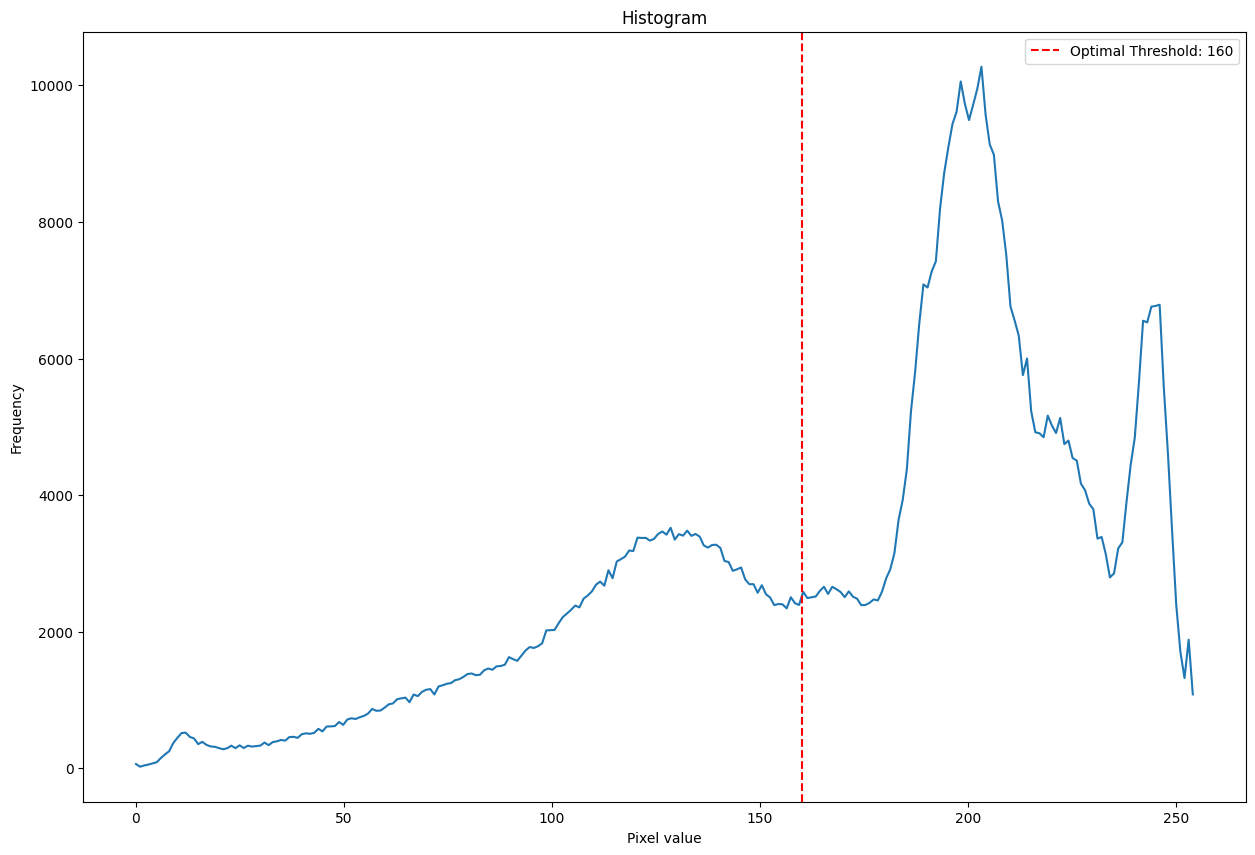

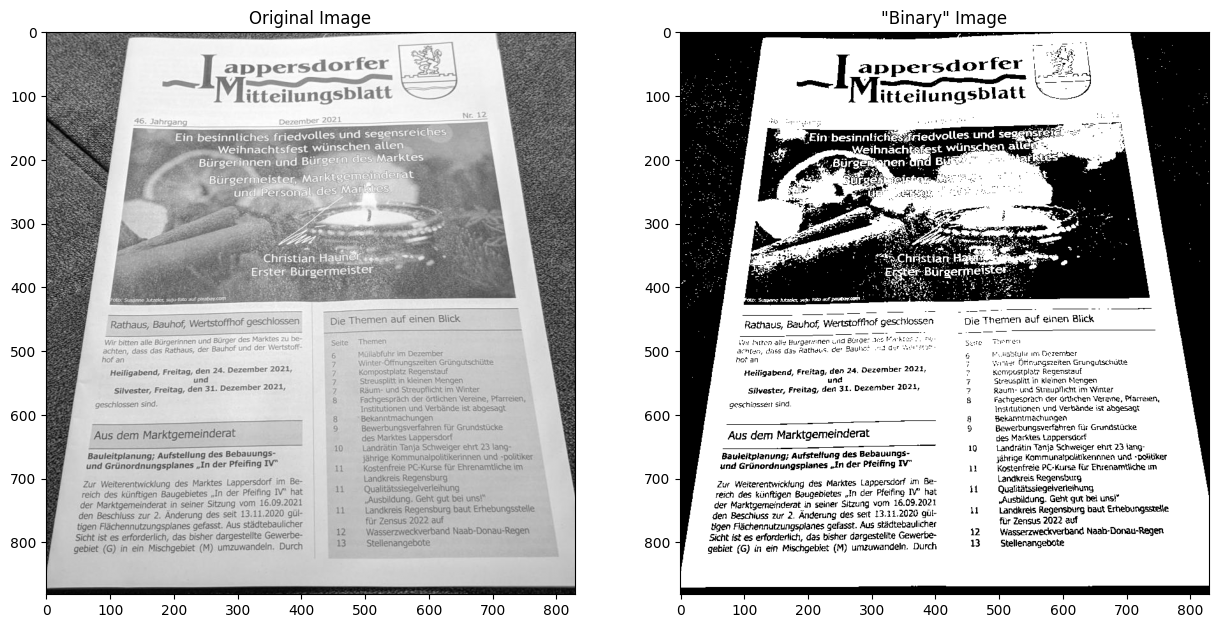

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

img = cv2.imread('../../data/lesson_8/document.jpg')

if img is None:
    print("Could not read the image.")
    raise FileNotFoundError("Image file not found. Please check the path and try again.")

img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# plt.imshow(img, cmap='gray')
# plt.show()

h = np.histogram(img, 256)

rows, cols = img.shape
num_pixels = img.size
print(f"Image dimensions: {rows}x{cols}")
print(f"Number of pixels: {num_pixels}")

best_wcv = 1e6
opt_th = None

for th in range(0, 256):
    foreground = img[img < th]
    background = img[img >= th]

    if len(foreground) == 0 or len(background) == 0:
        continue

    omega_f = len(foreground) / num_pixels
    omega_b = len(background) / num_pixels

    sigma2_f = np.var(foreground)
    sigma2_b = np.var(background)

    wcv = omega_f * sigma2_f + omega_b * sigma2_b

    if wcv < best_wcv:
        best_wcv = wcv
        opt_th = th

if opt_th is None:
    print("No optimal threshold found.")
    raise ValueError("Optimal threshold could not be determined. Please check the input image.")


plt.plot(h[1][:-1], h[0])
plt.title('Histogram')
plt.xlabel('Pixel value')
plt.ylabel('Frequency')
plt.axvline(opt_th, color='r', linestyle='--', label=f'Optimal Threshold: {opt_th}')
plt.legend()
plt.show()


plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title('Original Image')
plt.subplot(122), plt.imshow((img > opt_th).astype(np.uint8) * 255, cmap='gray'), plt.title('"Binary" Image')
plt.show()

Looking at the computed histogram, could it be considered bimodal?
> Не думаю, есть три пика, думаю первый: черный текст, второй серый фон, третий белый фон(лист бумаги). Ярко выражены с них два - серый и белый, черный более "размазан" по оси х. Но алгоритм выбрал пороговое значение(160) между черным и серым.

Looking at the computed histogram, what binarization threshold would you chose? Why?
> Я бы выбрал немного выше, где-то 180-185, тогда серый текст местами лучше бы виделился, но так же есть небольшой риск появления артеафактов и ложного выделения серого фона. По моему 160 хороший результат, но можно поискать лучшее значение в зависимости от сцены.

Looking at the resulting (thresholded) image, is the text binarization (detection) good?
> Да, текст читаемый, но есть пару мест где мы теряем часть текста который переходит в разряд фона. В целом, результат хороший как для гистограммы с тремя пиками, но при лучших входных данных (изображении с гистограммой где было бы два четких пика) можно было бы добится лучшего результата.